# 01 Parquet Prep — Clean Working Notebook

This notebook is for **data prep only**:
- inspect parquet files
- load spatial layers safely
- standardize CRS
- clip to North Slope extent
- run QA checks
- make a quick static preview

Keep heavier visualization work in a separate notebook.


## 0. Imports + display settings

In [1]:

from pathlib import Path
import pandas as pd
import geopandas as gpd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

base_dir = Path.cwd()
parquet_files = sorted(base_dir.glob("*.parquet"))

print(f"Working directory: {base_dir}")
print(f"Found {len(parquet_files)} parquet files")
for fp in parquet_files:
    print(" -", fp.name)


Working directory: /home/jovyan/notebooks
Found 6 parquet files
 - alaska_base_map.parquet
 - clean_2d_seismic.parquet
 - clean_3d_seismic.parquet
 - clean_well_locations.parquet
 - north_slope_assessment_units.parquet
 - north_slope_extent.parquet


## 1. Quick parquet inventory

In [2]:

def summarize_parquet(fp: Path) -> dict:
    row = {
        "file": fp.name,
        "size_mb": round(fp.stat().st_size / 1e6, 2),
        "rows": None,
        "cols": None,
        "has_geometry": None,
        "crs": None,
        "geometry_types": None,
        "all_null_cols": None,
        "error": None,
    }
    try:
        meta = pq.ParquetFile(fp).metadata
        row["rows"] = meta.num_rows

        try:
            gdf = gpd.read_parquet(fp)
            row["cols"] = len(gdf.columns)
            row["has_geometry"] = "geometry" in gdf.columns
            if "geometry" in gdf.columns:
                row["crs"] = str(gdf.crs)
                geom_types = gdf.geometry.geom_type.dropna().unique().tolist()
                row["geometry_types"] = ", ".join(geom_types[:5]) if geom_types else None
            row["all_null_cols"] = [c for c in gdf.columns if gdf[c].isna().all()]
        except Exception:
            df = pd.read_parquet(fp)
            row["cols"] = len(df.columns)
            row["has_geometry"] = "geometry" in df.columns
            row["all_null_cols"] = [c for c in df.columns if df[c].isna().all()]
    except Exception as e:
        row["error"] = str(e)
    return row

inventory_df = pd.DataFrame([summarize_parquet(fp) for fp in parquet_files])
inventory_df


,file,size_mb,rows,cols,has_geometry,crs,geometry_types,all_null_cols,error
0,alaska_base_map.parquet,0.11,9,169,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...",Polygon,"[BRK_GROUP, FORMAL_FR, NOTE_ADM0, NOTE_BRK, NA...",None
1,clean_2d_seismic.parquet,5.17,26,7,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...","MultiLineString, LineString",[],None
2,clean_3d_seismic.parquet,2.04,36,8,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...","Polygon, MultiPolygon",[],None
3,clean_well_locations.parquet,0.20,10250,4,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...",Point,[],None
4,north_slope_assessment_units.parquet,1.08,6,6,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...","Polygon, MultiPolygon",[],None
5,north_slope_extent.parquet,0.01,1,2,True,"{""$schema"": ""https://proj.org/schemas/v0.7/pro...",Polygon,[],None


## 2. Helper functions

In [3]:

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
    )
    return df

def load_spatial_parquet(fp: Path, fallback_crs=None) -> gpd.GeoDataFrame:
    gdf = gpd.read_parquet(fp)
    gdf = clean_column_names(gdf)

    if "geometry" not in gdf.columns:
        raise ValueError(f"{fp.name} does not contain a geometry column")

    gdf = gpd.GeoDataFrame(gdf, geometry="geometry")

    if gdf.crs is None and fallback_crs is not None:
        gdf = gdf.set_crs(fallback_crs, allow_override=True)

    return gdf

def reproject_if_needed(gdf: gpd.GeoDataFrame, target_crs="EPSG:4326") -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("CRS is missing; set a CRS before reprojection.")
    if str(gdf.crs) != target_crs:
        return gdf.to_crs(target_crs)
    return gdf

def qa_summary(name: str, gdf: gpd.GeoDataFrame) -> dict:
    return {
        "layer": name,
        "rows": len(gdf),
        "cols": len(gdf.columns),
        "crs": str(gdf.crs),
        "geom_types": ", ".join(sorted(set(gdf.geometry.geom_type.dropna().astype(str)))),
        "null_geometry": int(gdf.geometry.isna().sum()),
        "invalid_geometry": int((~gdf.geometry.is_valid).sum()) if gdf.geometry.notna().any() else 0,
        "bounds": tuple(round(x, 6) for x in gdf.total_bounds),
    }

def clip_to_extent(gdf: gpd.GeoDataFrame, extent_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if str(gdf.crs) != str(extent_gdf.crs):
        gdf = gdf.to_crs(extent_gdf.crs)
    return gpd.clip(gdf, extent_gdf)


## 3. Load key layers

Edit the filenames below only if your parquet names change.

In [4]:

FILES = {
    "base_map": "alaska_base_map.parquet",
    "north_slope_extent": "north_slope_extent.parquet",
    "assessment_units": "north_slope_assessment_units.parquet",
    "seismic_2d": "clean_2d_seismic.parquet",
    "seismic_3d": "clean_3d_seismic.parquet",
    "well_locations": "clean_well_locations.parquet",
}

missing = [name for name, fn in FILES.items() if not (base_dir / fn).exists()]
if missing:
    print("Missing files:")
    for name in missing:
        print(" -", name, "->", FILES[name])
else:
    print("All listed files are present.")


All listed files are present.


In [5]:

layers = {}

for layer_name, filename in FILES.items():
    fp = base_dir / filename
    if fp.exists():
        layers[layer_name] = load_spatial_parquet(fp)

print("Loaded layers:", list(layers.keys()))
for name, gdf in layers.items():
    print(name, "->", len(gdf), "rows | CRS:", gdf.crs)


Loaded layers: ['base_map', 'north_slope_extent', 'assessment_units', 'seismic_2d', 'seismic_3d', 'well_locations']
base_map -> 9 rows | CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "NAD83 / Alaska Albers", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "Alaska Albers (meter)", "method": {"name": "Albers Equal Area", "id": {"authority": "EPSG", "code": 9822}}, "parameters": [{"name": "Latitude of false origin", "value": 50, "unit": "degree", "id": {"authority

## 4. Standardize CRS

Use Alaska Albers first if you need a projected Alaska workflow, then convert to EPSG:4326 for web mapping.

In [6]:

# Optional: if any layer is missing a CRS and you know the source CRS, set it here.
# Example:
# layers["seismic_2d"] = layers["seismic_2d"].set_crs("EPSG:3338", allow_override=True)

for name, gdf in layers.items():
    if gdf.crs is None:
        print(f"WARNING: {name} has no CRS set.")


In [7]:

# Reproject everything to EPSG:4326 for consistency and later web mapping
for name, gdf in list(layers.items()):
    if gdf.crs is not None:
        layers[name] = reproject_if_needed(gdf, "EPSG:4326")

for name, gdf in layers.items():
    print(name, "->", gdf.crs)


base_map -> EPSG:4326
north_slope_extent -> EPSG:4326
assessment_units -> EPSG:4326
seismic_2d -> EPSG:4326
seismic_3d -> EPSG:4326
well_locations -> EPSG:4326


## 5. Light layer-specific cleanup

In [8]:

if "base_map" in layers and "NAME" in layers["base_map"].columns:
    layers["base_map"] = layers["base_map"][["NAME", "geometry"]].copy()

for name, gdf in layers.items():
    # drop exact duplicate records when possible
    non_geom_cols = [c for c in gdf.columns if c != "geometry"]
    if non_geom_cols:
        layers[name] = gdf.drop_duplicates(subset=non_geom_cols + ["geometry"]).copy()

for name, gdf in layers.items():
    print(name, "rows after cleanup:", len(gdf))


base_map rows after cleanup: 9
north_slope_extent rows after cleanup: 1
assessment_units rows after cleanup: 6
seismic_2d rows after cleanup: 26
seismic_3d rows after cleanup: 36
well_locations rows after cleanup: 9938


## 6. Clip layers to North Slope extent

In [9]:

clipped_layers = {}

if "north_slope_extent" not in layers:
    print("north_slope_extent layer not loaded; skipping clip step.")
else:
    extent = layers["north_slope_extent"]

    for name, gdf in layers.items():
        if name == "north_slope_extent":
            clipped_layers[name] = gdf.copy()
        else:
            clipped_layers[name] = clip_to_extent(gdf, extent)

    print("Clipped layers created:")
    for name, gdf in clipped_layers.items():
        print(name, "->", len(gdf), "rows")


Clipped layers created:
base_map -> 1 rows
north_slope_extent -> 1 rows
assessment_units -> 6 rows
seismic_2d -> 8 rows
seismic_3d -> 24 rows
well_locations -> 8066 rows


## 7. QA checks

In [10]:

qa_df = pd.DataFrame([qa_summary(name, gdf) for name, gdf in clipped_layers.items()]) if clipped_layers else pd.DataFrame()
qa_df


,layer,rows,cols,crs,geom_types,null_geometry,invalid_geometry,bounds
0,base_map,1,2,EPSG:4326,Polygon,0,0,"(-166.764441, 68.0, -140.985988, 71.357764)"
1,north_slope_extent,1,2,EPSG:4326,Polygon,0,0,"(-170.0, 68.0, -140.0, 71.8)"
2,assessment_units,6,6,EPSG:4326,"MultiPolygon, Polygon",0,0,"(-155.999001, 68.297261, -145.854631, 70.621449)"
3,seismic_2d,8,7,EPSG:4326,MultiLineString,0,0,"(-156.521837, 68.323482, -147.345427, 70.549471)"
4,seismic_3d,24,8,EPSG:4326,"MultiPolygon, Polygon",0,0,"(-155.969166, 69.281428, -147.758985, 71.057242)"
5,well_locations,8066,4,EPSG:4326,Point,0,0,"(-163.496639, 68.081273, -143.027702, 71.321116)"


In [11]:

for name, gdf in clipped_layers.items():
    print("=" * 100)
    print(name)
    print("Columns:", gdf.columns.tolist())
    print("Head:")
    display(gdf.head(2))


base_map
Columns: ['NAME', 'geometry']
Head:


,NAME,geometry
4,United States of America,"POLYGON ((-140.986 69.712, -140.989 68, -165.2..."


north_slope_extent
Columns: ['name', 'geometry']
Head:


,name,geometry
0,North Slope Study Area,"POLYGON ((-140 68, -140 71.8, -170 71.8, -170 ..."


assessment_units
Columns: ['region', 'province', 'tps_name', 'au_name', 'geometry', 'type']
Head:


...

,survey_name,year_acquired,year_released,company,line_miles,geometry,type
10,Sagwon 2D,2008.0,2018.0,Seismic Solutions,57.12,"MULTILINESTRING ((-150.32317 69.3672, -150.323...",2D
12,Franklin Bluffs 2D,2016.0,NaN,Schlumberger,NaN,"MULTILINESTRING ((-148.87863 69.65209, -148.87...",2D


seismic_3d
Columns: ['survey_name', 'year_acquired', 'year_released', 'company', 'square_miles', 'survey_type', 'geometry', 'type']
Head:


,survey_name,year_acquired,year_released,company,square_miles,survey_type,geometry,type
34,Umiat 3D (2D/3D Sold as a set),2008,2018.0,Seismic Ventures,85.91,2D and 3D,"POLYGON ((-152.49761 69.41933, -152.49676 69.4...",3D
35,Umiat 3D Reprocessing,2008,2023.0,Crescent Geo,85.90,3D,"POLYGON ((-152.49761 69.41933, -152.49676 69.4...",3D


well_locations
Columns: ['operator', 'field', 'geometry', 'type']
Head:


,operator,field,geometry,type
9181,BP Alaska Inc.,*EXPLORATORY,POINT (-150.86646 69.03202),well
9182,BP Alaska Inc.,*EXPLORATORY,POINT (-150.83336 69.2968),well


## 8. Optional export of cleaned clipped layers

In [12]:

EXPORT_CLEANED = False

if EXPORT_CLEANED:
    out_dir = base_dir / "cleaned_outputs"
    out_dir.mkdir(exist_ok=True)

    for name, gdf in clipped_layers.items():
        out_fp = out_dir / f"{name}_cleaned.parquet"
        gdf.to_parquet(out_fp)
        print("Saved:", out_fp)
else:
    print("Export is off. Set EXPORT_CLEANED = True to write files.")


Export is off. Set EXPORT_CLEANED = True to write files.


## 9. Quick static map preview

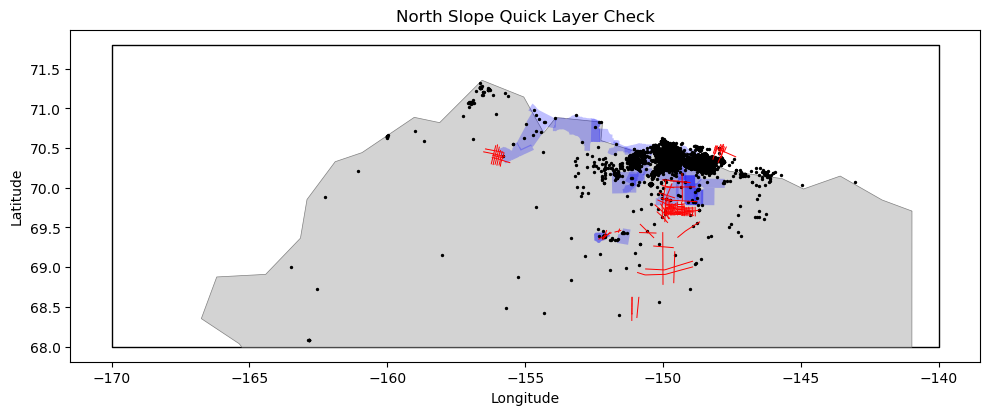

In [13]:

fig, ax = plt.subplots(figsize=(10, 10))

if "north_slope_extent" in clipped_layers:
    clipped_layers["north_slope_extent"].plot(ax=ax, color="none", edgecolor="black", linewidth=1)

if "base_map" in clipped_layers:
    clipped_layers["base_map"].plot(ax=ax, color="lightgray", edgecolor="gray", linewidth=0.5)

if "seismic_3d" in clipped_layers:
    clipped_layers["seismic_3d"].plot(ax=ax, color="blue", alpha=0.25)

if "seismic_2d" in clipped_layers:
    clipped_layers["seismic_2d"].plot(ax=ax, color="red", linewidth=0.7)

if "well_locations" in clipped_layers:
    clipped_layers["well_locations"].plot(ax=ax, color="black", markersize=2)

ax.set_title("North Slope Quick Layer Check")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [14]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# ===== SET OUTPUT FILE =====
output_file = Path("parquet_inspection_report.txt")

parquet_files = sorted(Path.cwd().glob("*.parquet"))

with open(output_file, "w") as f:

    f.write(f"FOUND {len(parquet_files)} PARQUET FILES\n\n")

    for fp in parquet_files:
        try:
            gdf = gpd.read_parquet(fp)

            f.write("="*100 + "\n")
            f.write(f"FILE: {fp.name}\n")
            f.write("="*100 + "\n")

            # Basic info
            f.write(f"Shape: {gdf.shape}\n")
            f.write(f"CRS: {gdf.crs}\n")
            f.write(f"Geometry Types: {gdf.geom_type.value_counts(dropna=False).to_dict()}\n\n")

            # Columns
            f.write("COLUMNS:\n")
            f.write(str(gdf.columns.tolist()) + "\n\n")

            # Dtypes
            f.write("DTYPES:\n")
            f.write(str(gdf.dtypes) + "\n\n")

            # Missing values
            f.write("MISSING VALUES (TOP 20):\n")
            na = gdf.isna().sum()
            na = na[na > 0].sort_values(ascending=False).head(20)
            f.write(str(na) + "\n\n")

            # Bounds
            try:
                f.write(f"TOTAL BOUNDS: {gdf.total_bounds}\n\n")
            except:
                f.write("TOTAL BOUNDS: ERROR\n\n")

            # Sample rows
            f.write("SAMPLE ROWS:\n")
            f.write(str(gdf.head(3)) + "\n\n")

            # Numeric summary
            num = gdf.select_dtypes(include=["number"])
            if not num.empty:
                f.write("NUMERIC SUMMARY:\n")
                f.write(str(num.describe().T) + "\n\n")
            else:
                f.write("NUMERIC SUMMARY: NONE\n\n")

            # Categorical preview
            obj_cols = gdf.select_dtypes(include=["object"]).columns.tolist()
            if obj_cols:
                f.write("CATEGORICAL VALUES (FIRST FEW PER COLUMN):\n")
                for col in obj_cols[:10]:  # limit to avoid huge file
                    try:
                        vals = gdf[col].dropna().astype(str).unique()[:20]
                        f.write(f"{col}: {vals}\n")
                    except:
                        f.write(f"{col}: ERROR\n")
                f.write("\n")
            else:
                f.write("CATEGORICAL VALUES: NONE\n\n")

        except Exception as e:
            f.write("="*100 + "\n")
            f.write(f"FILE: {fp.name}\n")
            f.write("ERROR READING FILE\n")
            f.write(str(e) + "\n\n")

print(f"\nReport saved to: {output_file.resolve()}")


Report saved to: /home/jovyan/notebooks/parquet_inspection_report.txt


/tmp/ipykernel_513/1341009779.py:60: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = gdf.select_dtypes(include=["object"]).columns.tolist()
/tmp/ipykernel_513/1341009779.py:60: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-

In [15]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np

# =========================================================
# 1. LOAD DATA
# =========================================================
base_dir = Path.cwd()

seis2d = gpd.read_parquet(base_dir / "clean_2d_seismic.parquet")
seis3d = gpd.read_parquet(base_dir / "clean_3d_seismic.parquet")
wells = gpd.read_parquet(base_dir / "clean_well_locations.parquet")
assessment = gpd.read_parquet(base_dir / "north_slope_assessment_units.parquet")
extent = gpd.read_parquet(base_dir / "north_slope_extent.parquet")

print("Loaded:")
print("  2D seismic:", seis2d.shape)
print("  3D seismic:", seis3d.shape)
print("  wells:", wells.shape)
print("  assessment:", assessment.shape)
print("  extent:", extent.shape)

# =========================================================
# 2. KEEP ANALYSIS COPIES IN EPSG:3338
#    (best for distance / area / length calculations)
# =========================================================
target_analysis_crs = "EPSG:3338"

seis2d = seis2d.to_crs(target_analysis_crs)
seis3d = seis3d.to_crs(target_analysis_crs)
wells = wells.to_crs(target_analysis_crs)
assessment = assessment.to_crs(target_analysis_crs)
extent = extent.to_crs(target_analysis_crs)

# =========================================================
# 3. BASIC FEATURE ENGINEERING
# =========================================================

# ---- 2D seismic features
seis2d["length_km"] = seis2d.geometry.length / 1000.0
seis2d["length_mi_geom"] = seis2d["length_km"] * 0.621371
seis2d["has_company"] = seis2d["company"].notna()
seis2d["has_release_year"] = seis2d["year_released"].notna()
seis2d["has_acquired_year"] = seis2d["year_acquired"].notna()
seis2d["survey_age_years"] = np.where(
    seis2d["year_acquired"].notna(),
    2026 - seis2d["year_acquired"],
    np.nan
)

# ---- 3D seismic features
seis3d["area_km2"] = seis3d.geometry.area / 1e6
seis3d["area_mi2_geom"] = seis3d["area_km2"] * 0.386102
seis3d["has_company"] = seis3d["company"].notna()
seis3d["has_release_year"] = seis3d["year_released"].notna()
seis3d["survey_age_years"] = np.where(
    seis3d["year_acquired"].notna(),
    2026 - seis3d["year_acquired"],
    np.nan
)

# ---- Assessment unit features
assessment["area_km2"] = assessment.geometry.area / 1e6
assessment["area_mi2_geom"] = assessment["area_km2"] * 0.386102

# ---- Well features
wells["has_geometry"] = wells.geometry.notna()
wells["has_field"] = wells["field"].notna()
wells["has_operator"] = wells["operator"].notna()
wells["is_exploratory"] = wells["field"].astype("string").str.contains("EXPLORATORY", case=False, na=False)
wells["is_strat_test"] = wells["field"].astype("string").str.contains("STRATIGRAPHIC", case=False, na=False)

# =========================================================
# 4. DROP NULL-GEOMETRY WELLS FOR SPATIAL OPERATIONS
# =========================================================
wells_spatial = wells[wells.geometry.notna()].copy()
print(f"\nWells with geometry: {len(wells_spatial)} / {len(wells)}")

# =========================================================
# 5. WELLS INSIDE 3D SEISMIC
# =========================================================
# dissolve 3D footprints into one coverage polygon
seis3d_union = seis3d.geometry.union_all()

wells_spatial["in_3d"] = wells_spatial.geometry.within(seis3d_union)

# distance to nearest 3D footprint boundary/area is optional; here simple inside/outside
print("Wells inside 3D coverage:", wells_spatial["in_3d"].sum())

# =========================================================
# 6. DISTANCE FROM EACH WELL TO NEAREST 2D SEISMIC LINE
# =========================================================
# unary union of all 2D lines for faster nearest-distance calculation
seis2d_union = seis2d.geometry.union_all()

wells_spatial["dist_to_2d_m"] = wells_spatial.geometry.distance(seis2d_union)
wells_spatial["dist_to_2d_km"] = wells_spatial["dist_to_2d_m"] / 1000.0
wells_spatial["dist_to_2d_mi"] = wells_spatial["dist_to_2d_km"] * 0.621371

# simple categorical helper
wells_spatial["near_2d_lt_1km"] = wells_spatial["dist_to_2d_km"] < 1
wells_spatial["near_2d_lt_5km"] = wells_spatial["dist_to_2d_km"] < 5
wells_spatial["near_2d_lt_10km"] = wells_spatial["dist_to_2d_km"] < 10

# =========================================================
# 7. SPATIAL JOIN: WELLS -> ASSESSMENT UNITS
# =========================================================
assessment_join_cols = ["au_name", "province", "tps_name", "region", "geometry"]

wells_joined = gpd.sjoin(
    wells_spatial,
    assessment[assessment_join_cols],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

wells_joined["in_assessment_unit"] = wells_joined["au_name"].notna()

print("Wells matched to assessment units:", wells_joined["in_assessment_unit"].sum())

# =========================================================
# 8. OPTIONAL: CLIP SEISMIC TO NORTH SLOPE EXTENT
#    keeps focus on study area
# =========================================================
extent_union = extent.geometry.union_all()

seis2d_ns = seis2d[seis2d.geometry.intersects(extent_union)].copy()
seis3d_ns = seis3d[seis3d.geometry.intersects(extent_union)].copy()
assessment_ns = assessment[assessment.geometry.intersects(extent_union)].copy()

# =========================================================
# 9. CONVERT TO EPSG:4326 FOR PLOTLY
# =========================================================
target_plotly_crs = "EPSG:4326"

seis2d_plotly = seis2d_ns.to_crs(target_plotly_crs)
seis3d_plotly = seis3d_ns.to_crs(target_plotly_crs)
wells_plotly = wells_joined.to_crs(target_plotly_crs)
assessment_plotly = assessment_ns.to_crs(target_plotly_crs)
extent_plotly = extent.to_crs(target_plotly_crs)

# centroid lat/lon helpers for polygons
for gdf, name in [
    (seis3d_plotly, "seis3d_plotly"),
    (assessment_plotly, "assessment_plotly"),
]:
    centroids = gdf.geometry.centroid
    gdf["centroid_lon"] = centroids.x
    gdf["centroid_lat"] = centroids.y

# point lat/lon helpers for wells
wells_plotly["lon"] = wells_plotly.geometry.x
wells_plotly["lat"] = wells_plotly.geometry.y

# =========================================================
# 10. SAVE FEATURE PARQUETS
# =========================================================
seis2d_plotly.to_parquet(base_dir / "clean_2d_seismic_features.parquet")
seis3d_plotly.to_parquet(base_dir / "clean_3d_seismic_features.parquet")
wells_plotly.to_parquet(base_dir / "clean_well_locations_features.parquet")
assessment_plotly.to_parquet(base_dir / "north_slope_assessment_units_features.parquet")
extent_plotly.to_parquet(base_dir / "north_slope_extent_features.parquet")

print("\nSaved:")
print("  clean_2d_seismic_features.parquet")
print("  clean_3d_seismic_features.parquet")
print("  clean_well_locations_features.parquet")
print("  north_slope_assessment_units_features.parquet")
print("  north_slope_extent_features.parquet")

# =========================================================
# 11. QUICK QA OUTPUT
# =========================================================
print("\n--- QA SUMMARY ---")
print("\n2D seismic columns:")
print(seis2d_plotly.columns.tolist())

print("\n3D seismic columns:")
print(seis3d_plotly.columns.tolist())

print("\nWells columns:")
print(wells_plotly.columns.tolist())

print("\nAssessment columns:")
print(assessment_plotly.columns.tolist())

print("\nWell feature preview:")
preview_cols = [
    "operator", "field", "type", "has_field", "is_exploratory", "is_strat_test",
    "in_3d", "dist_to_2d_km", "au_name", "province", "tps_name", "lat", "lon"
]
preview_cols = [c for c in preview_cols if c in wells_plotly.columns]
print(wells_plotly[preview_cols].head())

print("\nCounts:")
print("  Wells in 3D:", wells_plotly["in_3d"].sum())
print("  Wells in assessment units:", wells_plotly["in_assessment_unit"].sum())
print("  Wells <1 km from 2D:", wells_plotly["near_2d_lt_1km"].sum())
print("  Wells <5 km from 2D:", wells_plotly["near_2d_lt_5km"].sum())
print("  Wells <10 km from 2D:", wells_plotly["near_2d_lt_10km"].sum())

Loaded:
  2D seismic: (26, 7)
  3D seismic: (36, 8)
  wells: (10250, 4)
  assessment: (6, 6)
  extent: (1, 2)

Wells with geometry: 9894 / 10250
Wells inside 3D coverage: 681
Wells matched to assessment units: 30934

Saved:
  clean_2d_seismic_features.parquet
  clean_3d_seismic_features.parquet
  clean_well_locations_features.parquet
  north_slope_assessment_units_features.parquet
  north_slope_extent_features.parquet

--- QA SUMMARY ---

2D seismic columns:
['survey_name', 'year_acquired', 'year_released', 'company', 'line_miles', 'geometry', 'type', 'length_km', 'length_mi_geom', 'has_company', 'has_release_year', 'has_acquired_year', 'survey_age_years']

3D seismic columns:
['survey_name', 'year_acquired', 'year_released', 'company', 'square_miles', 'survey_type', 'geometry', 'type', 'area_km2', 'area_mi2_geom', 'has_company', 'has_release_year', 'survey_age_years', 'centroid_lon', 'centroid_lat']

Wells columns:
['operator', 'field', 'geometry', 'type', 'has_geometry', 'has_field',

/tmp/ipykernel_513/1977120847.py:148: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/tmp/ipykernel_513/1977120847.py:148: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path.cwd()

wells_plotly = gpd.read_parquet(base_dir / "clean_well_locations_features.parquet")
assessment_plotly = gpd.read_parquet(base_dir / "north_slope_assessment_units_features.parquet")

print("Current wells rows:", len(wells_plotly))

# ---------------------------------------------------------
# 1. Build a stable well id from original attributes + coords
# ---------------------------------------------------------
wells_plotly["well_id"] = (
    wells_plotly["operator"].astype("string").fillna("NA") + " | " +
    wells_plotly["field"].astype("string").fillna("NA") + " | " +
    wells_plotly["lat"].round(6).astype(str) + " | " +
    wells_plotly["lon"].round(6).astype(str)
)

# ---------------------------------------------------------
# 2. Inspect duplication caused by spatial join
# ---------------------------------------------------------
dup_counts = wells_plotly["well_id"].value_counts()
print("Unique wells:", dup_counts.shape[0])
print("Duplicated wells:", (dup_counts > 1).sum())
print("Max duplicate matches for one well:", dup_counts.max())

print("\nTop duplicated wells:")
print(dup_counts.head(10))

# ---------------------------------------------------------
# 3. Show which assessment units overlap for duplicated wells
# ---------------------------------------------------------
dupe_ids = dup_counts[dup_counts > 1].index[:10]
dupe_preview = wells_plotly[wells_plotly["well_id"].isin(dupe_ids)][
    ["well_id", "operator", "field", "au_name", "province", "tps_name", "in_3d", "dist_to_2d_km", "lat", "lon"]
].sort_values(["well_id", "au_name"])

print("\nDuplicate preview:")
print(dupe_preview.head(30))

# ---------------------------------------------------------
# 4. Collapse back to one row per well
#    Keep first non-null AU fields, preserve well attributes
# ---------------------------------------------------------
def first_non_null(series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) > 0 else np.nan

wells_dedup = (
    wells_plotly
    .sort_values(["well_id", "au_name"], na_position="last")
    .groupby("well_id", as_index=False)
    .agg({
        "operator": "first",
        "field": "first",
        "geometry": "first",
        "type": "first",
        "has_geometry": "max",
        "has_field": "max",
        "has_operator": "max",
        "is_exploratory": "max",
        "is_strat_test": "max",
        "in_3d": "max",
        "dist_to_2d_m": "min",
        "dist_to_2d_km": "min",
        "dist_to_2d_mi": "min",
        "near_2d_lt_1km": "max",
        "near_2d_lt_5km": "max",
        "near_2d_lt_10km": "max",
        "au_name": first_non_null,
        "province": first_non_null,
        "tps_name": first_non_null,
        "region": first_non_null,
        "in_assessment_unit": "max",
        "lon": "first",
        "lat": "first",
    })
)

print("\nDeduplicated wells rows:", len(wells_dedup))
print("Unique well ids after dedup:", wells_dedup["well_id"].nunique())

# ---------------------------------------------------------
# 5. Save fixed well parquet
# ---------------------------------------------------------
wells_dedup = gpd.GeoDataFrame(wells_dedup, geometry="geometry", crs="EPSG:4326")
wells_dedup.to_parquet(base_dir / "clean_well_locations_features_dedup.parquet")

print("\nSaved: clean_well_locations_features_dedup.parquet")

# ---------------------------------------------------------
# 6. Corrected QA counts
# ---------------------------------------------------------
print("\n--- CORRECTED QA COUNTS ---")
print("Wells total:", len(wells_dedup))
print("Wells in 3D:", int(wells_dedup["in_3d"].sum()))
print("Wells in assessment units:", int(wells_dedup["in_assessment_unit"].sum()))
print("Wells <1 km from 2D:", int(wells_dedup["near_2d_lt_1km"].sum()))
print("Wells <5 km from 2D:", int(wells_dedup["near_2d_lt_5km"].sum()))
print("Wells <10 km from 2D:", int(wells_dedup["near_2d_lt_10km"].sum()))

print("\nAssessment unit counts:")
print(wells_dedup["au_name"].value_counts(dropna=False))

Current wells rows: 33078
Unique wells: 9861
Duplicated wells: 7732
Max duplicate matches for one well: 8

Top duplicated wells:
well_id
Hilcorp North Slope, LLC | PRUDHOE BAY | 70.264385 | -148.411057         8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.271381 | -149.900855    8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.264255 | -149.898434    8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.277353 | -149.686566    8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.275204 | -149.688761    8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.33496 | -149.804805     8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.33106 | -149.402176     8
ConocoPhillips Alaska, Inc. | KUPARUK RIVER | 70.327074 | -149.419905    8
Hilcorp Alaska, LLC | MILNE POINT | 70.452383 | -149.663891              8
BP Exploration (Alaska) Inc. | MILNE POINT | 70.46711 | -149.629512      8
Name: count, dtype: int64[pyarrow]

Duplicate preview:
                                                well_id   